# Algoritmo de Lógica Difusa

La lógica difusa se basa en varios pasos clave: definición de conjuntos difusos, aplicación de funciones de pertenencia, evaluación de reglas difusas y desdifusificación. Aquí te explico cada uno de estos pasos de manera matemática.

## 1. Definición de Conjuntos Difusos

Un conjunto difuso ( $A$ ) en un universo ( $X$ ) se define mediante una función de pertenencia ( $\mu _{A(x)}$ ), donde ( $\mu _{A(x)} $) es un valor entre 0 y 1 que indica el grado de pertenencia del elemento ( $x$ ) al conjunto $ A $.

$$ \mu_A: X \rightarrow [0, 1] $$

## 2. Funciones de Pertenencia

Las funciones de pertenencia más comunes incluyen la función triangular y la función trapezoidal.

### Función Triangular

La función triangular se define como:

$$ \mu_A(x) = \max\left( \min\left( \frac{x - a}{b - a}, \frac{c - x}{c - b} \right), 0 \right) $$

donde $ a $, $ b $, y $ c $ son los puntos que definen el triángulo.

### Función Trapezoidal

La función trapezoidal se define como:

$$ \mu_A(x) = \max\left( \min\left( \frac{x - a}{b - a}, 1, \frac{d - x}{d - c} \right), 0 \right) $$

donde $ a $, $ b $, $ c $, y $ d $ son los puntos que definen el trapezoide.

## 3. Evaluación de Reglas Difusas

Las reglas difusas se evalúan utilizando operadores lógicos difusos como AND, OR y NOT.

### Operador AND (Intersección)

El operador AND se define como el mínimo de los grados de pertenencia:

$$ \mu_{A \cap B}(x) = \min(\mu_A(x), \mu_B(x)) $$

### Operador OR (Unión)

El operador OR se define como el máximo de los grados de pertenencia:

$$ \mu_{A \cup B}(x) = \max(\mu_A(x), \mu_B(x)) $$

### Operador NOT (Complemento)

El operador NOT se define como:

$$ \mu_{\neg A}(x) = 1 - \mu_A(x) $$

## 4. Desdifusificación

La desdifusificación convierte los resultados difusos en un valor crisp. Un método común es el método del centroide.

### Método del Centroide

El valor crisp $ x^* $ se calcula como el centroide de la región bajo la curva de la función de pertenencia agregada:

$$ x^* = \frac{\int x \mu(x) \, dx}{\int \mu(x) \, dx} $$

donde $ \mu(x) $ es la función de pertenencia agregada.




## Ejemplo Matemático

Supongamos que tenemos una variable de entrada $ x $ y queremos determinar su pertenencia a tres conjuntos difusos: bajo, medio y alto.

### Definición de Conjuntos Difusos

- **Bajo**: Función triangular con $ a = 0 $, $ b = 25 $, $ c = 50 $
- **Medio**: Función trapezoidal con $ a = 25 $, $ b = 50 $, $ c = 75 $, $ d = 100 $
- **Alto**: Función triangular con $ a = 50 $, $ b = 75 $, $ c = 100 $



In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Definir funciones de pertenencia
def triangular_membership(x, a, b, c):
    
    return np.maximum(np.minimum((x - a) / (b - a), (c - x) / (c - b)), 0)

def trapezoidal_membership(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x - a) / (b - a), 1), (d - x) / (d - c)), 0)

def fuzzy_sets(x):
    low = triangular_membership(x, 0, 25, 50)
    medium = trapezoidal_membership(x, 25, 50, 75, 100)
    high = triangular_membership(x, 50, 75, 100)
    return low, medium, high


### Funciones de Pertenencia

- **Bajo**:

$$ \mu_{\text{bajo}}(x) = \max\left( \min\left( \frac{x - 0}{25 - 0}, \frac{50 - x}{50 - 25} \right), 0 \right) $$

- **Medio**:

$$ \mu_{\text{medio}}(x) = \max\left( \min\left( \frac{x - 25}{50 - 25}, 1, \frac{100 - x}{100 - 75} \right), 0 \right) $$

- **Alto**:

$$ \mu_{\text{alto}}(x) = \max\left( \min\left( \frac{x - 50}{75 - 50}, \frac{100 - x}{100 - 75} \right), 0 \right) $$



In [24]:
def fuzzy_rules(low, medium, high):
    if low > medium and low > high:
        return 'low'
    elif medium > low and medium > high:
        return 'medium'
    else:
        return 'high'




### Desdifusificación

Para desdifusificar, utilizamos el método del centroide:

$$ x^* = \frac{\int x \mu(x) \, dx}{\int \mu(x) \, dx} $$

donde $ \mu(x) $ es la función de pertenencia agregada.

In [25]:
def defuzzify(x, membership_values):
    numerator = np.sum(x * membership_values)
    denominator = np.sum(membership_values)
    return numerator / denominator


### Evaluación de Reglas Difusas

Supongamos que tenemos las siguientes reglas difusas:

1. Si $ x $ es bajo, entonces $ y $ es bajo.
2. Si $ x $ es medio, entonces $ y $ es medio.
3. Si $ x $ es alto, entonces $ y $ es alto.

Para un valor de entrada $ x = 30 $:

- **Bajo**:

$$ \mu_{\text{bajo}}(30) = \max\left( \min\left( \frac{30 - 0}{25 - 0}, \frac{50 - 30}{50 - 25} \right), 0 \right) = \max\left( \min\left( 1.2, 0.8 \right), 0 \right) = 0.8 $$

- **Medio**:

$$ \mu_{\text{medio}}(30) = \max\left( \min\left( \frac{30 - 25}{50 - 25}, 1, \frac{100 - 30}{100 - 75} \right), 0 \right) = \max\left( \min\left( 0.2, 1, 0.8 \right), 0 \right) = 0.2 $$

- **Alto**:

$$ \mu_{\text{alto}}(30) = \max\left( \min\left( \frac{30 - 50}{75 - 50}, \frac{100 - 30}{100 - 75} \right), 0 \right) = \max\left( \min\left( -0.8, 0.8 \right), 0 \right) = 0 $$


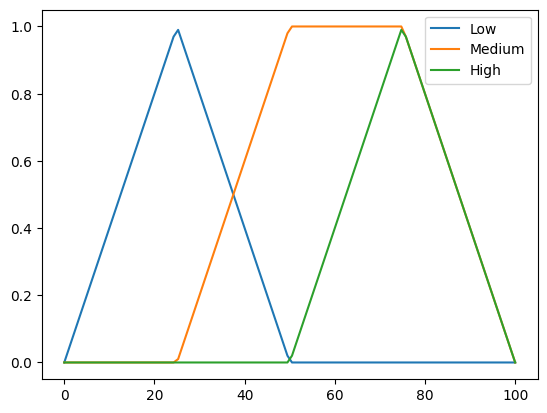

Input value: 30, Fuzzy result: low
Crisp value: 30.0


In [70]:
# Ejemplo de uso
x = np.linspace(0, 100, 100)
low, medium, high = fuzzy_sets(x)

# Graficar las funciones de pertenencia
plt.plot(x, low, label='Low')
plt.plot(x, medium, label='Medium')
plt.plot(x, high, label='High')
plt.legend()
plt.show()

# Ejemplo de evaluación
input_value = 30
low_value, medium_value, high_value = fuzzy_sets(np.linspace(input_value,input_value,1))
result = fuzzy_rules(low_value, medium_value, high_value)
print(f"Input value: {input_value}, Fuzzy result: {result}")

# Desdifusificación
membership_values = np.maximum(low, medium, high)
crisp_value = defuzzify(input_value, membership_values)
print(f"Crisp value: {crisp_value}")

# Fuzzy Logic with CUDA

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float32

# Definir funciones de pertenencia en CUDA
@cuda.jit
def triangular_membership_kernel(x, a, b, c, result):
    idx = cuda.grid(1)
    if idx < x.size:
        result[idx] = max(min((x[idx] - a) / (b - a), (c - x[idx]) / (c - b)), 0)

@cuda.jit
def trapezoidal_membership_kernel(x, a, b, c, d, result):
    idx = cuda.grid(1)
    if idx < x.size:
        result[idx] = max(min((x[idx] - a) / (b - a), 1, (d - x[idx]) / (d - c)), 0)

# Definir conjuntos difusos en CUDA
@cuda.jit
def fuzzy_sets_kernel(x, low, medium, high):
    idx = cuda.grid(1)
    if idx < x.size:
        low[idx] = max(min((x[idx] - 0) / (25 - 0), (50 - x[idx]) / (50 - 25)), 0)
        medium[idx] = max(min((x[idx] - 25) / (50 - 25), 1, (100 - x[idx]) / (100 - 75)), 0)
        high[idx] = max(min((x[idx] - 50) / (75 - 50), (100 - x[idx]) / (100 - 75)), 0)

# Definir reglas difusas en CUDA
@cuda.jit
def fuzzy_rules_kernel(low, medium, high, result):
    idx = cuda.grid(1)
    if idx < low.size:
        if low[idx] > medium[idx] and low[idx] > high[idx]:
            result[idx] = 0  # low
        elif medium[idx] > low[idx] and medium[idx] > high[idx]:
            result[idx] = 1  # medium
        else:
            result[idx] = 2  # high

# Desdifusificación utilizando el método del centroide en CUDA
@cuda.jit
def defuzzify_kernel(x, membership_values, numerator, denominator):
    idx = cuda.grid(1)
    if idx < x.size:
        cuda.atomic.add(numerator, 0, x[idx] * membership_values[idx])
        cuda.atomic.add(denominator, 0, membership_values[idx])

# Ejemplo de uso
x = np.linspace(0, 100, 100, dtype=np.float32)
low = np.zeros_like(x)
medium = np.zeros_like(x)
high = np.zeros_like(x)
result = np.zeros_like(x, dtype=np.int32)

# Configuración de la cuadrícula y los bloques
threads_per_block = 32
blocks_per_grid = (x.size + (threads_per_block - 1)) // threads_per_block

# Lanzar los kernels
fuzzy_sets_kernel[blocks_per_grid, threads_per_block](x, low, medium, high)
fuzzy_rules_kernel[blocks_per_grid, threads_per_block](low, medium, high, result)

# Graficar las funciones de pertenencia
plt.plot(x, low, label='Low')
plt.plot(x, medium, label='Medium')
plt.plot(x, high, label='High')
plt.legend()
plt.show()

# Desdifusificación
membership_values = np.maximum(low, medium, high)
numerator = np.zeros(1, dtype=np.float32)
denominator = np.zeros(1, dtype=np.float32)

defuzzify_kernel[blocks_per_grid, threads_per_block](x, membership_values, numerator, denominator)

crisp_value = numerator[0] / denominator[0]
print(f"Crisp value: {crisp_value}")


ModuleNotFoundError: No module named 'numba'